In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid
from srm.utils import open_icechunk

import os

var = "pr"
ssp_ens = "008"
g6_ens = "003"
hist_ens = "r3i1p1f1"

# Raw data
raw_data = catalog.get("CESM2-WACCM").to_xarray()
raw_ssp = raw_data["ssp245"][var].sel(ensemble_member=ssp_ens)
raw_historical = raw_data["historical"][var].sel(ensemble_member=hist_ens)
raw_g6 = raw_data["g6_1p5k"][var].sel(ensemble_member=g6_ens)
era5 = catalog.get('ERA5').to_xarray()

ilat = 1.5
ilon = -82.5

train_slice=slice("1978-01-01","2014-12-31")
fut_slice=slice("2040-01-01","2069-12-31")

raw_ssp_pt = raw_ssp.sel(lat=ilat, lon=ilon, method='nearest')
raw_g6_pt = raw_g6.sel(lat=ilat, lon=ilon, method='nearest')
raw_historical_pt = raw_historical.sel(lat=ilat, lon=ilon, method='nearest').sel(time=train_slice)
era5_pt = era5.sel(lat=ilat, lon=ilon, method='nearest')[var].sel(time=train_slice)

In [2]:
import point_debias_diagnostic as pdd

In [3]:
import importlib
importlib.reload(pdd)

<module 'point_debias_diagnostic' from '/scratch/synced/notebooks/QA_QC/pr/point_debias_diagnostic.py'>

In [4]:
results = pdd.run_analysis(era5_pt, raw_historical_pt, raw_ssp_pt, raw_g6_pt)

Running nonparametric_hybrid_2sided debiasing (ssp245)...


/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: cm_future contains inf or nan values. Not all debiasers support missing values and their presence might lead to infs or nans inside of the debiased values. Consider infilling the missing values.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:562: UserWarning: The debiaser output contains inf or nan values. This might be due to inf or nan values inside the input, or to a problem of the debiaser for the given dataset at hand. It is recommended to check the output carefully
  self._check_output(output)


Running nonparametric_hybrid_2sided debiasing (g6-1.5k)...

(1) Parametric vs nonparametric usage
[ssp245] 31046 days total
  parametric (Weibull low tail):      19 days (0.06%)
  parametric (Gumbel high tail):     106 days (0.34%)
  parametric (either tail):          125 days (0.40%)
  nonparametric:                   30921 days (99.60%)

[g6-1.5k] 25569 days total
  parametric (Weibull low tail):      29 days (0.11%)
  parametric (Gumbel high tail):     111 days (0.43%)
  parametric (either tail):          140 days (0.55%)
  nonparametric:                   25429 days (99.45%)

(2) Does debiasing distort the g6 - ssp245 mean difference, 2040-2069?
Raw       g6 - ssp245 mean (2040-2069):  -2.408291e-06
Debiased  g6 - ssp245 mean (2040-2069):  -3.700083e-06
Distortion (debiased - raw):              -1.291792e-06  (-53.6% of the raw delta)

  ssp245: debiasing shifted the mean by -2.210549e-06
  g6:     debiasing shifted the mean by -3.502340e-06
  -> if these two shifts are similar, de

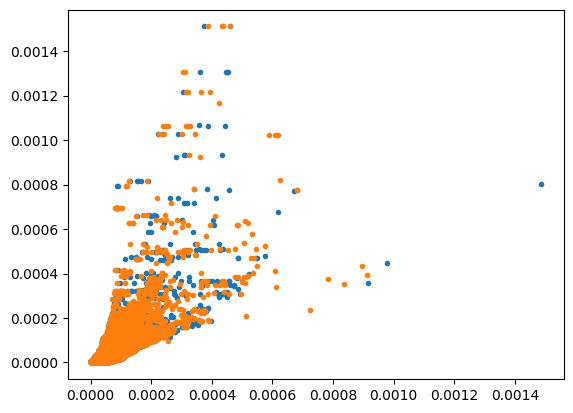

In [5]:
plt.plot(raw_g6_pt.sel(time=fut_slice),results["debiased_g6"].sel(time=fut_slice),'.')
plt.plot(raw_ssp_pt.sel(time=fut_slice),results["debiased_ssp"].sel(time=fut_slice),'.')

# Compare with actual output of pipeline

In [15]:
from srm.utils import open_icechunk
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
branch = "v0.11.1"
coarse_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
)[var]

coarse_debiased_g6 = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/g6_1p5k/" + var + "/" + g6_ens,
)[var]

coarse_debiased_ssp_pt=coarse_debiased_ssp.sel(lat=ilat,lon=ilon, method='nearest').sel(time=fut_slice)

coarse_debiased_g6_pt=coarse_debiased_g6.sel(lat=ilat,lon=ilon, method='nearest').sel(time=fut_slice)

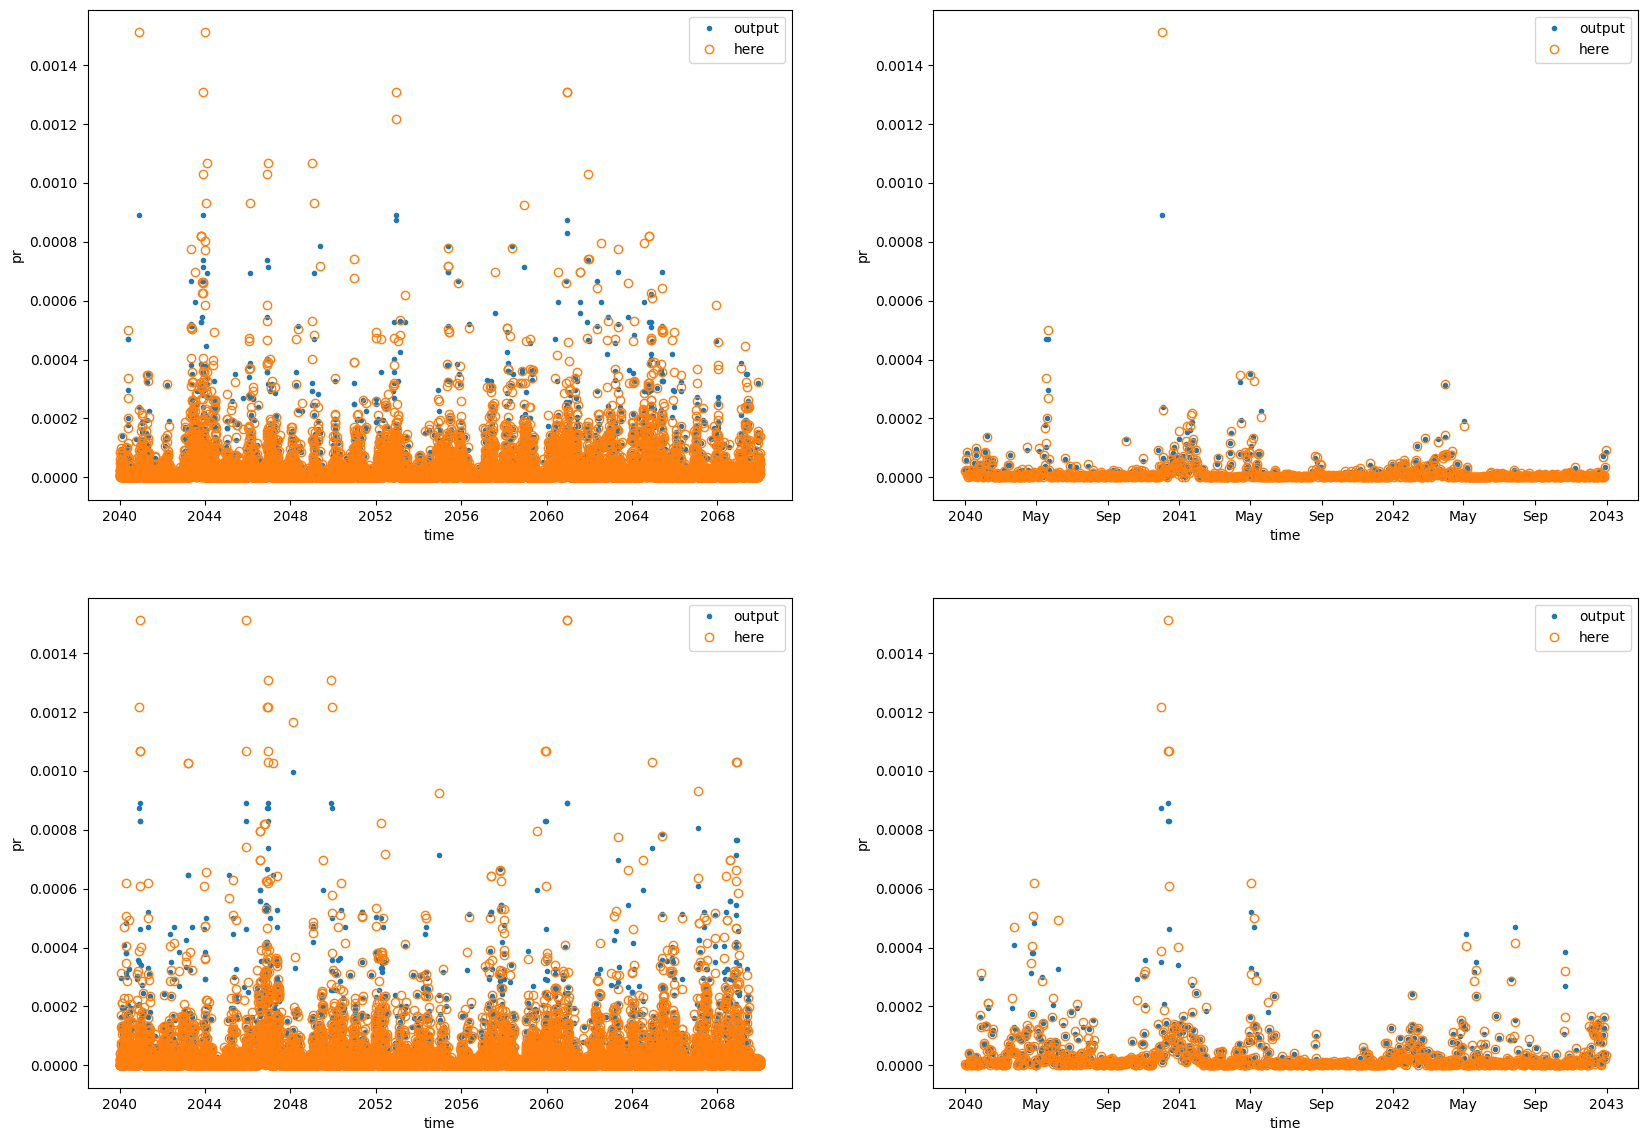

In [23]:
plt.figure(figsize=(20,14))
plt.subplot(2,2,1)
coarse_debiased_g6_pt.plot(label='output',marker='.',linestyle='none')
(results["debiased_g6"]).sel(time=fut_slice).plot(label='here', marker='o',fillstyle='none',linestyle='none')
plt.legend()

plt.subplot(2,2,2)
coarse_debiased_g6_pt[0:365*3].plot(label='output',marker='.',linestyle='none')
(results["debiased_g6"]).sel(time=fut_slice)[0:365*3].plot(label='here', marker='o',fillstyle='none',linestyle='none')
plt.legend()

plt.subplot(2,2,3)
coarse_debiased_ssp_pt.plot(label='output',marker='.',linestyle='none')
(results["debiased_ssp"]).sel(time=fut_slice).plot(label='here', marker='o',fillstyle='none',linestyle='none')
plt.legend()

plt.subplot(2,2,4)
coarse_debiased_ssp_pt[0:365*3].plot(label='output',marker='.',linestyle='none')
(results["debiased_ssp"]).sel(time=fut_slice)[0:365*3].plot(label='here', marker='o',fillstyle='none',linestyle='none')
plt.legend()
#plt.plot(raw_ssp_pt.sel(time=fut_slice),coarse_debiased_ssp_pt,'.')

In [25]:
import numpy as np
import xarray as xr

def compare_to_production(name, my_debiased, production_debiased, out_of_range_low=None, out_of_range_high=None):
    """Compares my_debiased (this script's output) against production_debiased
    (the real coarse_debiased_*_pt you already extracted), aligned on time.
    Breaks the difference down by which branch (nonparametric vs. parametric
    low/high tail) each day went through, if masks are supplied, so we can see
    directly whether the divergence concentrates in the ~99% nonparametric days
    or the <1% parametric days.
    """
    mine, prod = xr.align(my_debiased, production_debiased, join="inner")
    diff = mine - prod
    n = diff.time.size

    print(f"[{name}] {n} overlapping days")
    print(f"  mean(mine):        {float(mine.mean()):.6e}")
    print(f"  mean(production):  {float(prod.mean()):.6e}")
    print(f"  mean(mine - prod): {float(diff.mean()):.6e}")
    print(f"  mine > production: {100 * float((diff > 0).mean()):.1f}% of days")
    print(f"  max |diff|:        {float(np.abs(diff).max()):.6e}")
    print(f"  corr(mine, prod):  {float(xr.corr(mine, prod)):.6f}")

    if out_of_range_low is not None and out_of_range_high is not None:
        low_a, high_a, diff_a = xr.align(out_of_range_low, out_of_range_high, diff, join="inner")
        is_low = low_a & ~high_a
        is_high = high_a
        is_nonparam = ~low_a & ~high_a
        for label, mask in [("nonparametric", is_nonparam), ("Weibull low tail", is_low), ("Gumbel high tail", is_high)]:
            n_branch = int(mask.sum())
            if n_branch == 0:
                print(f"  {label:18s}: 0 days")
                continue
            branch_mean_diff = float(diff_a.where(mask).mean())
            print(f"  {label:18s}: {n_branch:6d} days, mean(mine - prod) = {branch_mean_diff:+.6e}")

    # monthly breakdown, to see if the bias is seasonal/uniform
    print("  by month:")
    diff_monthly = diff.groupby("time.month").mean()
    for month in range(1, 13):
        val = float(diff_monthly.sel(month=month))
        print(f"    month {month:2d}: mean(mine - prod) = {val:+.6e}")

    return diff


diff_ssp = compare_to_production(
    "ssp245", results["debiased_ssp"], coarse_debiased_ssp_pt,
    results["out_of_range_low_ssp"], results["out_of_range_high_ssp"],
)
print()
diff_g6 = compare_to_production(
    "g6-1.5k", results["debiased_g6"], coarse_debiased_g6_pt,
    results["out_of_range_low_g6"], results["out_of_range_high_g6"],
)

[ssp245] 10958 overlapping days
  mean(mine):        3.927706e-05
  mean(production):  3.718678e-05
  mean(mine - prod): 2.090276e-06
  mine > production: 39.2% of days
  max |diff|:        6.221575e-04
  corr(mine, prod):  0.981079
  nonparametric     :  10864 days, mean(mine - prod) = +1.970387e-06
  Weibull low tail  :     13 days, mean(mine - prod) = -4.514423e-09
  Gumbel high tail  :     81 days, mean(mine - prod) = +1.850637e-05
  by month:
    month  1: mean(mine - prod) = +8.357863e-07
    month  2: mean(mine - prod) = -5.178397e-07
    month  3: mean(mine - prod) = +1.648406e-06
    month  4: mean(mine - prod) = +1.754659e-06
    month  5: mean(mine - prod) = +5.051661e-07
    month  6: mean(mine - prod) = +3.385669e-06
    month  7: mean(mine - prod) = +2.845077e-06
    month  8: mean(mine - prod) = +1.716924e-06
    month  9: mean(mine - prod) = +8.355909e-08
    month 10: mean(mine - prod) = +1.338532e-06
    month 11: mean(mine - prod) = +1.515345e-06
    month 12: mean(m